### Train a model with 200 classes and save it and its label encoder

In [16]:
import os
import json
import shutil
import pickle
import numpy as np
import matplotlib.pyplot as plt
import joblib
import seaborn as sns

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking, BatchNormalization, Bidirectional, MaxPooling1D, GlobalMaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam
from keras.utils import plot_model
from collections import Counter
import tensorflow as tf
from tensorflow.keras import layers, Model, regularizers
from sklearn.utils.class_weight import compute_class_weight

In [2]:
data_directory = '../all_outputs/output_include'

# list all the files in directories and sub directories in in data_direcotiry and store them list_list list
file_names = []

for root, _, files in os.walk(data_directory):  # Walk through all directories and subdirectories
        for filename in files:
            file_names.append(os.path.join(root, filename))

print(len(file_names))            

4022


In [6]:
all_data = []

# Define indices for points of interest
pose_indices = [0, 15, 16, 17, 18, 19, 20]
hand_indices = [0, 4, 7, 8, 11, 12, 15, 16, 19, 20]

In [7]:

def load_landmarks(filenames, num_frames, glossIndex = 4):
    
    
    # Prepare storage for data and labels
    video_data = []
    labels = []
    
    for file in filenames:
     
        # print(file)
        gloss = file.split('/')[glossIndex]
        # print(gloss)


        with open(file, 'rb') as f:
                landmarks = pickle.load(f)
                    
                # Prepare frame storage for each video with fixed number of frames
                frames = []

                # Get frame sampling step (skip frames if necessary)
                total_frames = len(landmarks)
                step = max(1, total_frames // num_frames)
                    
                # Process frames
                for i in range(num_frames):
                    frame_index = i * step if total_frames >= num_frames else i
                    
                    if frame_index < total_frames:
                        frame = landmarks[frame_index]
                    else:
                        frame = None
                        
                    # Extract and flatten required points
                    pose_points = frame['pose_landmarks'] if frame and frame['pose_landmarks'] else [None] * 33
                    left_hand_points = frame['left_hand_landmarks'] if frame and frame['left_hand_landmarks'] else [None] * 21
                    right_hand_points = frame['right_hand_landmarks'] if frame and frame['right_hand_landmarks'] else [None] * 21
                        
                    # Collect only specified indices and flatten them
                    extracted_points = []

                    # Collect pose points first
                    for idx in pose_indices:
                        point = pose_points[idx] if pose_points[idx] is not None else {'x': 0, 'y': 0}
                        extracted_points.extend([point['x'], point['y']])
                        
                    # print(left_hand_points)
                    for idx in hand_indices:
                        point = left_hand_points[idx] if left_hand_points[idx] is not None else {'x': 0, 'y': 0}
                        extracted_points.extend([point['x'], point['y']])

                    # Collect right hand points
                    for idx in hand_indices:
                        point = right_hand_points[idx] if right_hand_points[idx] is not None else {'x': 0, 'y': 0}
                        extracted_points.extend([point['x'], point['y']])
                        
                    frames.append(extracted_points)
                    
                # Add the processed video frames to the main array
                video_data.append(frames)
                labels.append(gloss)
                

    # Convert to numpy arrays
    video_data = np.array(video_data)
    labels = np.array(labels)
    
    return video_data, labels

# Example usage
num_frames = 30  # Desired fixed number of frames per video

video_data, labels = load_landmarks(file_names, num_frames)

# `video_data` has shape (number of videos, num_frames, number of points*2) where points*2 is the flattened landmark count
# `labels` contains the labels for each video


In [8]:
print(f"Loaded data: {video_data.shape}, Labels: {labels.shape}")

Loaded data: (4022, 30, 54), Labels: (4022,)


In [10]:
# Select top 240 classes
CUSTOM_NUM_CLASSES = 240
class_counts = Counter(labels)
top_classes = [cls for cls, count in class_counts.most_common(CUSTOM_NUM_CLASSES)]
print(f"Selected {len(top_classes)} classes")

# Filter dataset
filtered_indices = [i for i, label in enumerate(labels) if label in top_classes]
video_data_filtered = video_data[filtered_indices]
labels_filtered = labels[filtered_indices]
print(f"Filtered data: {video_data_filtered.shape}")

# Encode labels
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels_filtered)
labels_one_hot = to_categorical(labels_encoded, num_classes=CUSTOM_NUM_CLASSES)

# Save LabelEncoder
label_encoder_path = '../saved_models/book_13/label_encoder_240.pkl'
joblib.dump(label_encoder, label_encoder_path)
print(f"Saved LabelEncoder to {label_encoder_path}")

# Split dataset
X_train, X_temp, y_train, y_temp = train_test_split(
    video_data_filtered, labels_one_hot, test_size=0.4, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.6, random_state=42
)
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# Data augmentation
def augment_data(x):
    noise = tf.random.normal(shape=tf.shape(x), mean=0.0, stddev=0.01)
    return x + noise

X_train_augmented = augment_data(X_train)
print(f"Augmented train data: {X_train_augmented.shape}")

Selected 240 classes
Filtered data: (4014, 30, 54)
Saved LabelEncoder to ../saved_models/book_13/label_encoder_240.pkl
Train: (2408, 30, 54), Val: (642, 30, 54), Test: (964, 30, 54)
Augmented train data: (2408, 30, 54)


2025-04-13 14:30:38.348832: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-04-13 14:30:38.492245: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-04-13 14:30:38.492523: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

In [14]:
# Define PositionEmbedding layer
class PositionEmbedding(layers.Layer):
    def __init__(self, config):
        super(PositionEmbedding, self).__init__()
        self.position_embeddings = self.add_weight(
            name="position_embeddings",
            shape=(config.max_position_embeddings, config.hidden_size),
            initializer="random_normal",
            trainable=True,
        )
    
    def call(self, x):
        seq_length = tf.shape(x)[1]
        positions = tf.range(start=0, limit=seq_length, delta=1)
        position_embeddings = tf.gather(self.position_embeddings, positions)
        return x + position_embeddings

# Define Transformer model
class Transformer(Model):
    def __init__(self, config, n_classes=240):
        super(Transformer, self).__init__()
        self.l1 = layers.Dense(config.hidden_size, activation=None, kernel_regularizer=regularizers.l2(0.001))
        self.embedding = PositionEmbedding(config)
        
        self.transformer_layers = [
            layers.MultiHeadAttention(
                num_heads=config.num_attention_heads, 
                key_dim=config.hidden_size // config.num_attention_heads,
                kernel_regularizer=regularizers.l2(0.001)
            )
            for _ in range(config.num_hidden_layers)
        ]
        
        self.layer_norms = [
            layers.LayerNormalization(epsilon=1e-6)
            for _ in range(config.num_hidden_layers)
        ]
        
        self.l2 = layers.Dense(n_classes, activation=None, kernel_regularizer=regularizers.l2(0.001))
        self.dropout = layers.Dropout(0.3)
        
    def call(self, x, training=False):
        x = self.l1(x)
        x = self.embedding(x)
        
        for i, layer in enumerate(self.transformer_layers):
            x = layer(x, x)
            x = self.layer_norms[i](x)
        
        x = tf.reduce_max(x, axis=1)
        x = self.dropout(x, training=training)
        x = self.l2(x)
        return x

In [ ]:
# Configuration
class Config:
    input_size = X_train.shape[2]
    hidden_size = 128
    num_hidden_layers = 4
    num_attention_heads = 8
    max_position_embeddings = num_frames
    num_classes = CUSTOM_NUM_CLASSES

config = Config()

# Build and compile model
model = Transformer(config, n_classes=config.num_classes)
model.build(input_shape=(None, config.max_position_embeddings, config.input_size))
model.summary()

# Compute class weights
y_train_indices = np.argmax(y_train, axis=1)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_indices),
    y=y_train_indices
)
class_weights = dict(enumerate(class_weights))

# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True, label_smoothing=0.1),
    metrics=['accuracy']
)

# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train model
history = model.fit(
    X_train_augmented,
    y_train,
    validation_data=(X_val, y_val),
    epochs=250,
    batch_size=32,
    callbacks=[early_stopping],
    class_weight=class_weights
)

# Evaluate model
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Save model weights
model_path = '../saved_models/book_13/transformer_240_classes.h5'
model.save_weights(model_path)
print(f"Saved model weights to {model_path}")

Model: "transformer_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             multiple                  7040      
                                                                 
 position_embedding_1 (Posi  multiple                  3840      
 tionEmbedding)                                                  
                                                                 
 multi_head_attention_4 (Mu  multiple                  66048     
 ltiHeadAttention)                                               
                                                                 
 multi_head_attention_5 (Mu  multiple                  66048     
 ltiHeadAttention)                                               
                                                                 
 multi_head_attention_6 (Mu  multiple                  66048     
 ltiHeadAttention)                                   

2025-04-13 14:33:20.641124: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7fb162d9e160 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-04-13 14:33:20.641152: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce GTX 1660 Ti, Compute Capability 7.5
2025-04-13 14:33:20.677777: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:255] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-04-13 14:33:20.734833: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8600
2025-04-13 14:33:20.938440: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


76/76 [==============================] - 8s 15ms/step - loss: 6.3062 - accuracy: 0.0042 - val_loss: 5.9857 - val_accuracy: 0.0031
Epoch 2/250
76/76 [==============================] - 1s 11ms/step - loss: 6.1246 - accuracy: 0.0037 - val_loss: 5.9007 - val_accuracy: 0.0109
Epoch 3/250
76/76 [==============================] - 1s 10ms/step - loss: 6.0159 - accuracy: 0.0066 - val_loss: 5.7752 - val_accuracy: 0.0078
Epoch 4/250
76/76 [==============================] - 1s 10ms/step - loss: 5.8988 - accuracy: 0.0091 - val_loss: 5.6685 - val_accuracy: 0.0047
Epoch 5/250
76/76 [==============================] - 1s 10ms/step - loss: 5.7548 - accuracy: 0.0096 - val_loss: 5.5627 - val_accuracy: 0.0125
Epoch 6/250
76/76 [==============================] - 1s 11ms/step - loss: 5.6840 - accuracy: 0.0100 - val_loss: 5.5064 - val_accuracy: 0.0140
Epoch 7/250
76/76 [==============================] - 1s 10ms/step - loss: 5.6336 - accuracy: 0.0145 - val_loss: 5.4429 - val_accuracy: 0.0171
Epoch 8/250
76/76 

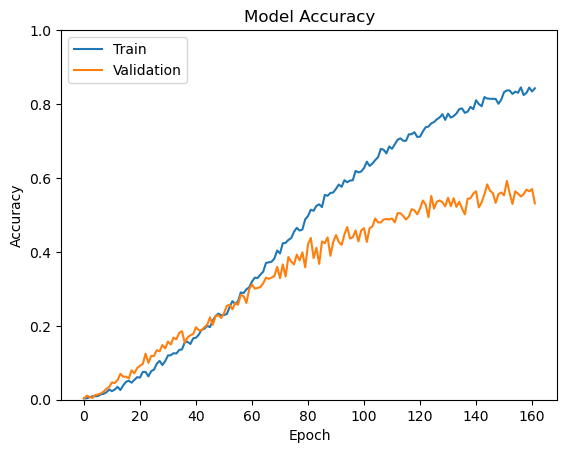

In [18]:
# Plot training and validation accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.ylim(0, 1)
plt.legend(['Train', 'Validation'], loc='upper left')
save_plt = plt
plt.show()